# CIFAR-10 Image Classification using CNN

## Import Libraries

In [1]:
import tensorflow as tf 
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

## Load CIFAR-10 Dataset

In [2]:
(X_train, y_train), (X_test, y_test)=datasets.cifar10.load_data()

## Data Preprocessing

In [3]:
# Reshaping 
y_train = y_train.reshape(-1,)
y_test = y_test.reshape(-1,)

# Normalization
X_train = X_train / 255.0
X_test = X_test / 255.0

## Visualize Sample Images

In [4]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [5]:
def plot_sample(X, y, index):
    plt.figure(figsize=(15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

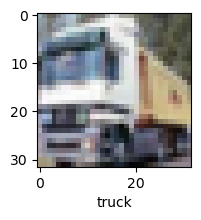

In [6]:
plot_sample(X_train, y_train, 1)

## Build CNN Model

In [7]:
cnn = models.Sequential([
    #cnn
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    #dense 
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


C:\Users\HUSSAIN\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Train Model and Measure Training Time

In [8]:
import time

start_time = time.time()

history = cnn.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.1
)

end_time = time.time()

print(f"Training Time: {end_time - start_time:.2f} seconds")

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.4484 - loss: 1.5249 - val_accuracy: 0.5386 - val_loss: 1.2946
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5765 - loss: 1.1999 - val_accuracy: 0.6102 - val_loss: 1.1041
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6224 - loss: 1.0668 - val_accuracy: 0.6460 - val_loss: 1.0275
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6561 - loss: 0.9856 - val_accuracy: 0.6666 - val_loss: 0.9640
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6743 - loss: 0.9253 - val_accuracy: 0.6748 - val_loss: 0.9571
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6925 - loss: 0.8777 - val_accuracy: 0.6634 - val_loss: 0.9672
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7056 - loss: 0.8376 - val_accuracy: 0.6804 - val_loss: 0.9157
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7197 - loss: 0.7972 - 

## Model Evaluation

In [9]:
y_pred = cnn.predict(X_test)
y_classes = [np.argmax(element) for element in y_pred]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step  


In [10]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy: ", accuracy_score(y_test, y_classes))
print("Classification Report: \n", classification_report(y_test, y_classes))

Accuracy:  0.6692
Classification Report: 
               precision    recall  f1-score   support

           0       0.74      0.71      0.72      1000
           1       0.78      0.83      0.80      1000
           2       0.63      0.42      0.51      1000
           3       0.47      0.46      0.46      1000
           4       0.58      0.65      0.61      1000
           5       0.47      0.68      0.55      1000
           6       0.80      0.69      0.74      1000
           7       0.71      0.75      0.73      1000
           8       0.80      0.79      0.79      1000
           9       0.81      0.72      0.76      1000

    accuracy                           0.67     10000
   macro avg       0.68      0.67      0.67     10000
weighted avg       0.68      0.67      0.67     10000



## Visualize Predictions

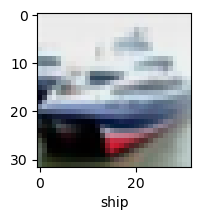

In [11]:
plot_sample(X_test, y_test, 1)

## Model Summary

In [12]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 253,760 (991.25 KB)

 Trainable params: 84,586 (330.41 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 169,174 (660.84 KB)

## Final Observations

- Built a basic CNN model for CIFAR-10 image classification.
- Achieved approximately 67% test accuracy.
- Total trainable parameters: 84,586.
- Training time was approximately 75.46 seconds.
- The CNN model successfully learned meaningful image features for CIFAR-10 classification.
- Future work includes comparison with ResNet50 and VGG16 architectures.